In [19]:
from sklearn.datasets import make_regression

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
from IPython.display import HTML, display

In [20]:
X, y = make_regression(
    n_samples=100,
    n_features=1,
    n_informative=1,
    n_targets=1,
    noise=20,
    random_state=13
)

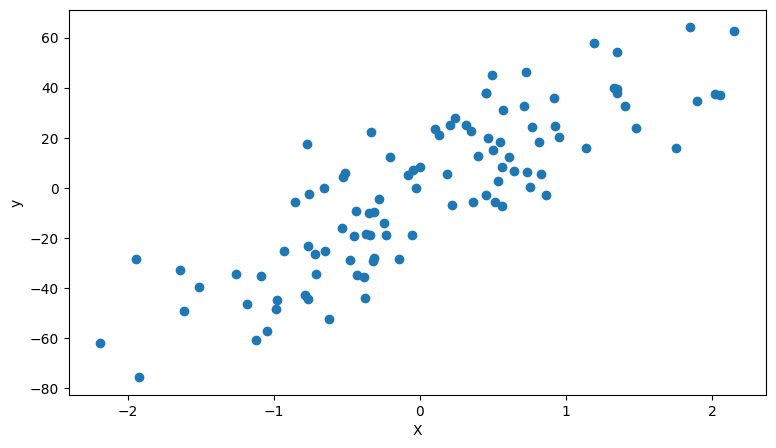

In [21]:
plt.figure(figsize=(9, 5))
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [28]:
b = -120
m = 100
lr = 0.001

all_b = []
all_m = []
all_cost = []

epochs = 30

for i in range(epochs):

    slope_b = 0
    slope_m = 0
    cost = 0

    for j in range(X.shape[0]):

        slope_b = slope_b - 2 * (
            y[j] - (m * X[j]) - b
        )

        slope_m = slope_m - 2 * (
            y[j] - (m * X[j]) - b
        ) * X[j]

        cost = cost + (
            y[j] - m * X[j] - b
        ) ** 2

    b = b - (lr * slope_b)
    m = m - (lr * slope_m)

    all_b.append(b)
    all_m.append(m)
    all_cost.append(cost)

<h1>Graph 1 — Regression line animation</h1>

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))

x_i = np.arange(-3, 3, 0.1)

ax.scatter(X.ravel(), y)
line, = ax.plot([], [], 'r-', linewidth=2)

ax.set_xlim(-3, 3)

def update(i):
    y_i = x_i * all_m[i] + all_b[i]

    line.set_data(x_i, y_i)
    ax.set_ylim(
        min(y.min(), y_i.min()) - 20,
        max(y.max(), y_i.max()) + 20
    )
    ax.set_xlabel(f"Epoch {i + 1}")

    return line,

anim = FuncAnimation(
    fig,
    update,
    frames=epochs,
    repeat=True,
    interval=500,
    blit=False
)

plt.close(fig)
display(HTML(anim.to_jshtml()))

<p><b>1. Regression line animation</b>

The graph displays the actual data points along with the regression line. At every epoch, Gradient Descent updates the slope and intercept, changing the position and tilt of the line. The animation helps us visualize how the model adjusts its line to fit the data. As learning progresses, the line should move toward a better fit, although the quality of convergence depends on the learning rate and the optimization process.</p>

<h1>Graph 2 — Cost function vs. epochs</h1>

In [30]:
num_epochs = list(range(1, epochs + 1))

fig, ax = plt.subplots(figsize=(9, 5))

line, = ax.plot([], [], lw=2)

ax.set_xlim(0, epochs + 1)
ax.set_ylim(
    0,
    max(all_cost) * 1.1 if max(all_cost) > 0 else 1
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Cost (sum of squared errors)")
ax.set_title("Cost Function vs Epoch")

def animate(i):
    line.set_data(
        num_epochs[:i + 1],
        all_cost[:i + 1]
    )
    return line,

anim = FuncAnimation(
    fig,
    animate,
    frames=epochs,
    repeat=False,
    interval=500,
    blit=False
)

plt.close(fig)
display(HTML(anim.to_jshtml()))

<p><b>2. Cost function vs. epochs</b>

The second graph displays the cost, calculated as the sum of squared differences between actual and predicted values, across epochs. It tells us whether the model is reducing its prediction errors during training. If the cost decreases, the model is generally improving; if it oscillates or increases, the updates may not be moving toward a minimum effectively. In this notebook, the cost is recorded before each epoch's parameter update.</p>

<h1>Graph 3 — Intercept (b) vs. epochs</h1>

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))

line, = ax.plot([], [], lw=2)

b_min, b_max = min(all_b), max(all_b)
b_margin = max((b_max - b_min) * 0.1, 1)

ax.set_xlim(0, epochs + 1)
ax.set_ylim(b_min - b_margin, b_max + b_margin)
ax.set_xlabel("Epoch")
ax.set_ylabel("Intercept (b)")
ax.set_title("Intercept vs Epoch")

def animate(i):
    line.set_data(
        num_epochs[:i + 1],
        all_b[:i + 1]
    )
    return line,

anim = FuncAnimation(
    fig,
    animate,
    frames=epochs,
    repeat=False,
    interval=500,
    blit=False
)

plt.close(fig)
display(HTML(anim.to_jshtml()))

<p><b>3. Intercept (b) vs. epochs</b>

The third graph tracks the intercept over successive epochs. The intercept controls the vertical position of the regression line: changing b shifts the line up or down without directly changing its slope. The graph shows how Gradient Descent adjusts this parameter in response to prediction errors. As training progresses, the intercept should approach a value that helps the line fit the data better.</p>

<h1>Graph 4 — Slope (m) vs. epochs</h1>

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))

line, = ax.plot([], [], lw=2)

m_min, m_max = min(all_m), max(all_m)
m_margin = max((m_max - m_min) * 0.1, 1)

ax.set_xlim(0, epochs + 1)
ax.set_ylim(m_min - m_margin, m_max + m_margin)
ax.set_xlabel("Epoch")
ax.set_ylabel("Slope (m)")
ax.set_title("Slope vs Epoch")

def animate(i):
    line.set_data(
        num_epochs[:i + 1],
        all_m[:i + 1]
    )
    return line,

anim = FuncAnimation(
    fig,
    animate,
    frames=epochs,
    repeat=False,
    interval=500,
    blit=False
)

plt.close(fig)
display(HTML(anim.to_jshtml()))

<p><b>4. Slope (m) vs. epochs</b>

The fourth graph tracks the slope over successive epochs. The slope controls how steep the regression line is and whether it rises or falls as the input increases. Gradient Descent updates m based on the gradient of the loss with respect to the slope. The graph shows these parameter updates and helps us understand how the model learns the line's tilt.

<b>Together, the four graphs show the complete learning process: the first visualizes the changing model, the second tracks its error, the third tracks its vertical position, and the fourth tracks its slope.</b></p>